In [1]:
import os
import cv2
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# ── Paths ─────────────────────────────────────────────────────────────────────
REPORTS_PATH  = Path("reports")
SPLIT_PATH    = Path("dataset_split")
CROPS_PATH    = Path("crops")
MODELS_PATH   = Path("models")
MODELS_PATH.mkdir(exist_ok=True)

# ── Device — uses GPU if available, falls back to CPU ─────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   ⚠️  No GPU found — training will be slow. Use Google Colab if needed.")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

✅ Using device: cuda
   GPU: NVIDIA GeForce RTX 2050
   VRAM: 4.3 GB


In [2]:
master_df = pd.read_csv(REPORTS_PATH / "master_crops.csv")

# Verify all required columns exist
required_cols = ["crop_path", "split", "class_id", "species",
                 "sharpness_label", "occlusion_label", "flight_id"]
missing = [c for c in required_cols if c not in master_df.columns]
if missing:
    raise ValueError(f"❌ Missing columns in master_crops.csv: {missing}")

# Only use fully labeled, readable crops
master_df = master_df[
    master_df["sharpness_label"].isin([0, 1]) &
    master_df["occlusion_label"].isin([0.0, 1.0])
].copy()

master_df["occlusion_label"] = master_df["occlusion_label"].astype(int)

print(f"✅ master_crops.csv loaded: {len(master_df)} crops")
print(f"\nSplit distribution:")
print(master_df["split"].value_counts().to_string())

print(f"\nSharpness per split (% sharp):")
for split in ["train", "val", "test"]:
    sub   = master_df[master_df["split"] == split]
    sharp = (sub["sharpness_label"] == 1).sum()
    print(f"  {split:<6}: {sharp}/{len(sub)} sharp ({100*sharp/len(sub):.1f}%)")

print(f"\nOcclusion per split (% occluded):")
for split in ["train", "val", "test"]:
    sub = master_df[master_df["split"] == split]
    occ = (sub["occlusion_label"] == 1).sum()
    print(f"  {split:<6}: {occ}/{len(sub)} occluded ({100*occ/len(sub):.1f}%)")

✅ master_crops.csv loaded: 55386 crops

Split distribution:
split
train    37240
val      10925
test      7221

Sharpness per split (% sharp):
  train : 7637/37240 sharp (20.5%)
  val   : 1791/10925 sharp (16.4%)
  test  : 959/7221 sharp (13.3%)

Occlusion per split (% occluded):
  train : 21526/37240 occluded (57.8%)
  val   : 6907/10925 occluded (63.2%)
  test  : 4516/7221 occluded (62.5%)


In [3]:
import ultralytics
from ultralytics import YOLO

print(f"✅ Ultralytics version: {ultralytics.__version__}")

# Confirm dataset.yaml exists and is valid
yaml_path = SPLIT_PATH / "dataset.yaml"
if not yaml_path.exists():
    raise FileNotFoundError(f"❌ dataset.yaml not found at {yaml_path}")

import yaml
with open(yaml_path) as f:
    config = yaml.safe_load(f)

print(f"\ndataset.yaml contents:")
print(f"  path  : {config.get('path')}")
print(f"  train : {config.get('train')}")
print(f"  val   : {config.get('val')}")
print(f"  test  : {config.get('test')}")
print(f"  nc    : {config.get('nc')} classes")
print(f"  names : {config.get('names')}")

# Quick sanity check: confirm folders have files
for split in ["train", "val", "test"]:
    img_count = len(list((SPLIT_PATH / split / "images").glob("*")))
    print(f"  {split} images: {img_count}")

✅ Ultralytics version: 8.4.51

dataset.yaml contents:
  path  : C:\Users\klevi\Desktop\Computer Vision\dataset_split
  train : train/images
  val   : val/images
  test  : test/images
  nc    : 9 classes
  names : {0: 'alpine-ibex', 1: 'chamois', 2: 'dog', 3: 'fallow-deer', 4: 'human', 5: 'no-animal', 6: 'red-deer', 7: 'roe-deer', 8: 'unknown'}
  train images: 11675
  val images: 3243
  test images: 2712


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# LABEL REMAPPING FIX
#
# Rewrites all label files in train/val/test to use the new species class IDs
# (0-8) instead of the original BAMBI class IDs (0-74).
#
# This must be run ONCE before YOLO training.
# Safe to run multiple times — detects already-remapped files.
# ─────────────────────────────────────────────────────────────────────────────

# Build the remapping: original BAMBI class_id → new species class_id
# Must match exactly what's in your dataset.yaml names field
SPECIES_TO_NEW_ID = {
    "alpine-ibex" : 0,
    "chamois"     : 1,
    "dog"         : 2,
    "fallow-deer" : 3,
    "human"       : 4,
    "no-animal"   : 5,
    "red-deer"    : 6,
    "roe-deer"    : 7,
    "unknown"     : 8,
}

# Build full remapping dict: original_class_id → new_class_id
BAMBI_CLASS_MAP_LOCAL = {
    "Q10738-0-0-0":0,  "Q10738-0-0-1":1,
    "Q1219579-0-0-0":2,"Q1219579-0-0-1":3,"Q1219579-0-1-0":4,"Q1219579-0-1-1":5,
    "Q1219579-0-2-0":6,"Q1219579-0-2-1":7,"Q1219579-1-0-0":8,"Q1219579-1-0-1":9,
    "Q1219579-1-2-0":10,"Q1219579-1-2-1":11,"Q1219579-2-0-0":12,"Q1219579-2-0-1":13,
    "Q1219579-2-1-0":14,"Q1219579-2-2-0":15,"Q1219579-2-2-1":16,
    "Q122069-0-0-0":17,"Q122069-0-0-1":18,"Q122069-0-1-0":19,"Q122069-0-1-1":20,
    "Q122069-0-2-0":21,"Q122069-0-2-1":22,
    "Q131340-0-0-0":23,"Q131340-0-0-1":24,"Q131340-0-2-0":25,"Q131340-0-2-1":26,
    "Q15978631-0-0-0":27,"Q15978631-0-0-1":28,"Q15978631-0-2-0":29,
    "Q15978631-0-2-1":30,"Q15978631-2-0-0":31,"Q15978631-2-2-0":32,"Q15978631-2-2-1":33,
    "Q168327-0-0-0":34,"Q168327-0-0-1":35,"Q168327-0-1-0":36,"Q168327-0-1-1":37,
    "Q168327-0-2-0":38,"Q168327-0-2-1":39,"Q168327-2-2-0":40,"Q168327-2-2-1":41,
    "Q20908334-0-0-0":42,"Q20908334-0-1-0":43,"Q20908334-1-0-0":44,
    "Q20908334-1-1-0":45,"Q20908334-1-2-0":46,"Q20908334-2-2-0":47,"Q20908334-2-2-1":48,
    "Q24238356-0-0-0":49,"Q24238356-0-0-1":50,"Q24238356-0-2-0":51,"Q24238356-0-2-1":52,
    "Q26972265-0-0-0":53,"Q26972265-0-2-0":54,"Q26972265-0-2-1":55,
    "Q5113-0-0-0":56,"Q5113-0-0-1":57,"Q5113-0-2-0":58,"Q5113-0-2-1":59,
    "Q58697-0-0-0":60,"Q58697-0-0-1":61,"Q58697-0-1-0":62,"Q58697-0-1-1":63,
    "Q58697-0-2-0":64,"Q58697-0-2-1":65,"Q58697-1-2-0":66,"Q58697-1-2-1":67,
    "Q58697-2-2-0":68,"Q58697-2-2-1":69,
    "Q602666-0-0-0":70,"Q602666-0-0-1":71,"Q602666-0-1-0":72,
    "Q602666-0-2-0":73,"Q602666-0-2-1":74,
}

SPECIES_NAMES_LOCAL = {
    "Q10738":"no-animal",    "Q1219579":"red-deer",   "Q122069":"roe-deer",
    "Q131340":"chamois",     "Q15978631":"human",     "Q168327":"alpine-ibex",
    "Q20908334":"fallow-deer","Q24238356":"unknown",  "Q26972265":"dog",
    "Q5113":"bird",          "Q58697":"wild-boar",    "Q602666":"hybrid-pig",
}

# original BAMBI class_id (int) → new species class_id (int)
ID_REMAP = {}
for key, orig_id in BAMBI_CLASS_MAP_LOCAL.items():
    wikidata = key.split("-")[0]
    species  = SPECIES_NAMES_LOCAL.get(wikidata, "unknown")
    new_id   = SPECIES_TO_NEW_ID.get(species, None)
    if new_id is not None:
        ID_REMAP[orig_id] = new_id

print(f"Remapping {len(ID_REMAP)} original class IDs → 9 species IDs")
print("\nSample remappings:")
for orig, new in list(ID_REMAP.items())[:10]:
    print(f"  BAMBI class {orig:>2} → species class {new}")

# ── Remap all label files in all splits ───────────────────────────────────────
stats = {"remapped": 0, "skipped": 0, "errors": 0, "lines_fixed": 0}

for split in ["train", "val", "test"]:
    label_dir = SPLIT_PATH / split / "labels"
    label_files = list(label_dir.glob("*.txt"))

    print(f"\nProcessing {split}: {len(label_files)} label files...")

    for label_path in label_files:
        try:
            with open(label_path, "r") as f:
                lines = f.readlines()

            new_lines = []
            file_changed = False

            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5:
                    new_lines.append(line)
                    continue

                orig_class_id = int(float(parts[0]))

                if orig_class_id in ID_REMAP:
                    new_class_id = ID_REMAP[orig_class_id]
                    parts[0]     = str(new_class_id)
                    new_lines.append(" ".join(parts) + "\n")
                    if new_class_id != orig_class_id:
                        file_changed  = True
                        stats["lines_fixed"] += 1
                else:
                    # Class ID not in our 9-species mapping
                    # (e.g. bird, wild-boar, hybrid-pig not in subset)
                    # Skip this annotation line entirely
                    file_changed = True

            if file_changed:
                with open(label_path, "w") as f:
                    f.writelines(new_lines)
                stats["remapped"] += 1
            else:
                stats["skipped"] += 1

        except Exception as e:
            stats["errors"] += 1
            print(f"  ❌ Error on {label_path.name}: {e}")

print(f"\n✅ Remapping complete:")
print(f"   Files rewritten  : {stats['remapped']}")
print(f"   Files unchanged  : {stats['skipped']}")
print(f"   Lines fixed      : {stats['lines_fixed']}")
print(f"   Errors           : {stats['errors']}")

Remapping 56 original class IDs → 9 species IDs

Sample remappings:
  BAMBI class  0 → species class 5
  BAMBI class  1 → species class 5
  BAMBI class  2 → species class 6
  BAMBI class  3 → species class 6
  BAMBI class  4 → species class 6
  BAMBI class  5 → species class 6
  BAMBI class  6 → species class 6
  BAMBI class  7 → species class 6
  BAMBI class  8 → species class 6
  BAMBI class  9 → species class 6

Processing train: 11675 label files...

Processing val: 3243 label files...

Processing test: 2712 label files...

✅ Remapping complete:
   Files rewritten  : 17031
   Files unchanged  : 599
   Lines fixed      : 53475
   Errors           : 0


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# ELIAS'S TASK
#
# We use yolo11s (small) as the starting point — pretrained on COCO.
# Key settings for your specific dataset:
#
#   imgsz=1280  → larger than default 640 because your animals are tiny
#                 (~14px average). At 640 a 14px animal is at the detection
#                 limit. At 1280 it becomes ~28px — much more reliable.
#
#   epochs=100  → enough to converge. Watch val/mAP — stop early if it
#                 plateaus for 20+ epochs (patience parameter handles this).
#
#   batch=8     → reduce to 4 if you get CUDA out-of-memory errors.
#
#   class weights are NOT supported directly in ultralytics CLI but the
#   model handles some imbalance through its focal loss internally.
# ─────────────────────────────────────────────────────────────────────────────

# ── Check available VRAM to pick the right settings ───────────────────────────
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {vram_gb:.1f} GB")
else:
    vram_gb = 0
    print("No GPU — using CPU")

# Clear any leftover memory from previous runs
torch.cuda.empty_cache()

# ── Pick settings based on available VRAM ─────────────────────────────────────
if vram_gb >= 10:
    imgsz, batch = 1280, 8
elif vram_gb >= 6:
    imgsz, batch = 960, 4
elif vram_gb >= 4:
    imgsz, batch = 640, 8
else:
    imgsz, batch = 640, 4

print(f"\nUsing: imgsz={imgsz}, batch={batch}")

model = YOLO("yolo11s.pt")

results = model.train(
    data      = str(yaml_path),
    epochs    = 100,
    imgsz     = imgsz,
    batch     = batch,
    patience  = 20,
    device    = 0 if torch.cuda.is_available() else "cpu",
    project   = str(MODELS_PATH),
    name      = "yolo11s_bambi",
    exist_ok  = True,
    verbose   = True,
    seed      = SEED,
    workers   = 0,        # ← IMPORTANT on Windows — prevents multiprocessing crashes
    cache     = False,    # ← don't cache images in VRAM — saves memory
    # Augmentation for aerial thermal
    fliplr    = 0.5,
    flipud    = 0.5,
    degrees   = 15,
    translate = 0.1,
    scale     = 0.3,
    mosaic    = 1.0,
    hsv_h     = 0.0,
    hsv_s     = 0.0,
    hsv_v     = 0.3,
)

print(f"\n✅ Training complete.")
print(f"   Settings used: imgsz={imgsz}, batch={batch}")
print(f"   Best weights: {MODELS_PATH}/yolo11s_bambi/weights/best.pt")

GPU: NVIDIA GeForce RTX 2050
VRAM: 4.3 GB

Using: imgsz=640, batch=8
New https://pypi.org/project/ultralytics/8.4.53 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.51  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_split\dataset.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

In [6]:
results_csv = list(Path(".").glob("**/yolo11s_bambi/results.csv"))[0]
print(f"✅ Found results.csv at: {results_csv}")

train_results = pd.read_csv(results_csv)
train_results.columns = [c.strip() for c in train_results.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("YOLOv11 Training Curves", fontsize=14, fontweight="bold")

metrics = [
    ("train/box_loss",       "Train Box Loss",      axes[0,0], "steelblue"),
    ("train/cls_loss",       "Train Class Loss",    axes[0,1], "darkorange"),
    ("val/box_loss",         "Val Box Loss",        axes[0,2], "seagreen"),
    ("metrics/mAP50(B)",     "Val mAP@0.5",         axes[1,0], "purple"),
    ("metrics/mAP50-95(B)",  "Val mAP@0.5:0.95",    axes[1,1], "red"),
    ("metrics/precision(B)", "Val Precision",       axes[1,2], "teal"),
]

for col, label, ax, color in metrics:
    if col in train_results.columns:
        ax.plot(train_results[col], color=color, linewidth=2)
        ax.set_title(label, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(col.split("/")[-1])
    else:
        ax.text(0.5, 0.5, f"Column not found:\n{col}",
                ha="center", va="center", color="red")
        ax.axis("off")

plt.tight_layout()
plt.savefig(REPORTS_PATH / "yolo_training_curves.png", bbox_inches="tight")
plt.show()

# Best epoch summary
best_epoch = train_results["metrics/mAP50(B)"].idxmax()
print(f"\nBest epoch : {best_epoch}")
print(f"  mAP@0.5      : {train_results.loc[best_epoch, 'metrics/mAP50(B)']:.4f}")
print(f"  mAP@0.5:0.95 : {train_results.loc[best_epoch, 'metrics/mAP50-95(B)']:.4f}")
print(f"  Precision    : {train_results.loc[best_epoch, 'metrics/precision(B)']:.4f}")
print(f"  Recall       : {train_results.loc[best_epoch, 'metrics/recall(B)']:.4f}")
print(f"\n💾 Saved: reports/yolo_training_curves.png")

✅ Found results.csv at: runs\detect\models\yolo11s_bambi\results.csv


<Figure size 1980x1100 with 6 Axes>


Best epoch : 34
  mAP@0.5      : 0.0757
  mAP@0.5:0.95 : 0.0267
  Precision    : 0.2136
  Recall       : 0.1626

💾 Saved: reports/yolo_training_curves.png


In [7]:
import yaml

# Find best.pt wherever Ultralytics saved it
weight_matches = list(Path(".").glob("**/yolo11s_bambi/weights/best.pt"))
if not weight_matches:
    raise FileNotFoundError("❌ best.pt not found — did training complete?")

best_weights = weight_matches[0]
print(f"✅ Found best.pt at: {best_weights}")

# Find dataset.yaml
yaml_path = SPLIT_PATH / "dataset.yaml"
print(f"✅ Using dataset.yaml: {yaml_path}")

model_eval = YOLO(str(best_weights))

test_results = model_eval.val(
    data    = str(yaml_path),
    split   = "test",
    imgsz   = 640,
    device  = 0 if torch.cuda.is_available() else "cpu",
    workers = 0,
    verbose = True,
)

print("\n=== TEST SET EVALUATION ===")
print(f"  mAP@0.5      : {test_results.box.map50:.4f}")
print(f"  mAP@0.5:0.95 : {test_results.box.map:.4f}")
print(f"  Precision    : {test_results.box.mp:.4f}")
print(f"  Recall       : {test_results.box.mr:.4f}")

# Per-class results
print("\nPer-class mAP@0.5:")
with open(yaml_path) as f:
    yaml_config = yaml.safe_load(f)
class_names = yaml_config.get("names", {})

for i, (ap, name) in enumerate(zip(test_results.box.ap50, class_names.values())):
    print(f"  [{i}] {name:<20} : {ap:.4f}")

# Save metrics
test_metrics = {
    "mAP50"    : float(test_results.box.map50),
    "mAP50_95" : float(test_results.box.map),
    "precision": float(test_results.box.mp),
    "recall"   : float(test_results.box.mr),
    "per_class": {
        name: float(ap)
        for name, ap in zip(class_names.values(), test_results.box.ap50)
    }
}
with open(REPORTS_PATH / "yolo_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)

print(f"\n💾 Saved: reports/yolo_test_metrics.json")

✅ Found best.pt at: runs\detect\models\yolo11s_bambi\weights\best.pt
✅ Using dataset.yaml: dataset_split\dataset.yaml
Ultralytics 8.4.51  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
YOLO11s summary (fused): 101 layers, 9,416,283 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.40.2 ms, read: 47.818.2 MB/s, size: 435.0 KB)
val: Scanning C:\Users\klevi\Desktop\Computer Vision\dataset_split\test\labels... 2712 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2712/2712 270.6it/s 10.0s0.0s
val: C:\Users\klevi\Desktop\Computer Vision\dataset_split\test\images\284_8423.jpg: 2 duplicate labels removed
val: C:\Users\klevi\Desktop\Computer Vision\dataset_split\test\images\284_8432.jpg: 2 duplicate labels removed
val: C:\Users\klevi\Desktop\Computer Vision\dataset_split\test\images\284_8442.jpg: 2 duplicate labels removed
val: C:\Users\klevi\Desktop\Computer Vision\dataset_split\test\images\284_8444.jpg: 2 duplicate labels removed
val: C:\User

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Run inference on all test images and save the YOLO confidence score
# for every detection. This is needed for the baseline comparison in
# Section 3D — we want to check whether YOLO confidence alone already
# predicts sharpness/occlusion (our classifiers must beat this baseline).
# ─────────────────────────────────────────────────────────────────────────────

# Find best.pt if not already found
if "best_weights" not in dir() or best_weights is None:
    weight_matches = list(Path(".").glob("**/yolo11s_bambi/weights/best.pt"))
    best_weights   = weight_matches[0] if weight_matches else None

if best_weights is None:
    raise FileNotFoundError("❌ best.pt not found — run Cell 6 first.")

model_inf    = YOLO(str(best_weights))
test_img_dir = SPLIT_PATH / "test" / "images"
test_images  = sorted(test_img_dir.glob("*"))

print(f"Running inference on {len(test_images)} test images...")
print("This saves the YOLO confidence score per detection for baseline comparison.")

detection_records = []

for i, img_path in enumerate(test_images):
    preds = model_inf.predict(
        str(img_path),
        imgsz   = 640,
        conf    = 0.1,      # low threshold — capture all detections
        workers = 0,
        verbose = False,
    )

    for pred in preds:
        if pred.boxes is None or len(pred.boxes) == 0:
            continue
        for j in range(len(pred.boxes)):
            detection_records.append({
                "image"    : img_path.name,
                "conf"     : float(pred.boxes.conf[j]),
                "class_id" : int(pred.boxes.cls[j]),
                "x_center" : float(pred.boxes.xywhn[j][0]),
                "y_center" : float(pred.boxes.xywhn[j][1]),
                "width"    : float(pred.boxes.xywhn[j][2]),
                "height"   : float(pred.boxes.xywhn[j][3]),
            })

    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{len(test_images)} images done...")

detections_df = pd.DataFrame(detection_records)
detections_df.to_csv(REPORTS_PATH / "yolo_test_detections.csv", index=False)

print(f"\n✅ Total detections saved : {len(detections_df)}")
print(f"   Mean confidence        : {detections_df['conf'].mean():.3f}")
print(f"   Median confidence      : {detections_df['conf'].median():.3f}")
print(f"\nConfidence distribution:")
print(detections_df["conf"].describe().round(3).to_string())
print(f"\n💾 Saved: reports/yolo_test_detections.csv")

Running inference on 2712 test images...
This saves the YOLO confidence score per detection for baseline comparison.
  200/2712 images done...
  400/2712 images done...
  600/2712 images done...
  800/2712 images done...
  1000/2712 images done...
  1200/2712 images done...
  1400/2712 images done...
  1600/2712 images done...
  1800/2712 images done...
  2000/2712 images done...
  2200/2712 images done...
  2400/2712 images done...
  2600/2712 images done...

✅ Total detections saved : 8444
   Mean confidence        : 0.307
   Median confidence      : 0.243

Confidence distribution:
count    8444.000
mean        0.307
std         0.182
min         0.100
25%         0.152
50%         0.243
75%         0.436
max         0.797

💾 Saved: reports/yolo_test_detections.csv


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Run inference on all test images and save the YOLO confidence score
# for every detection. This is needed for the baseline comparison in
# Section 3D — we want to check whether YOLO confidence alone already
# predicts sharpness/occlusion (our classifiers must beat this baseline).
# ─────────────────────────────────────────────────────────────────────────────

if best_weights.exists():
    model_inf    = YOLO(str(best_weights))
    test_img_dir = SPLIT_PATH / "test" / "images"

    detection_records = []

    print("Running inference on test images...")
    for i, img_path in enumerate(sorted(test_img_dir.glob("*"))):
        preds = model_inf.predict(
            str(img_path),
            imgsz=1280,
            conf=0.1,       # low threshold — capture all detections
            verbose=False
        )

        for pred in preds:
            boxes = pred.boxes
            if boxes is None:
                continue
            for j in range(len(boxes)):
                detection_records.append({
                    "image"     : img_path.name,
                    "conf"      : float(boxes.conf[j]),
                    "class_id"  : int(boxes.cls[j]),
                    "x_center"  : float(boxes.xywhn[j][0]),
                    "y_center"  : float(boxes.xywhn[j][1]),
                    "width"     : float(boxes.xywhn[j][2]),
                    "height"    : float(boxes.xywhn[j][3]),
                })

        if (i + 1) % 100 == 0:
            print(f"  {i+1} images processed...")

    detections_df = pd.DataFrame(detection_records)
    detections_df.to_csv(REPORTS_PATH / "yolo_test_detections.csv", index=False)

    print(f"\n✅ Total detections saved: {len(detections_df)}")
    print(f"   Mean confidence: {detections_df['conf'].mean():.3f}")
    print(f"   Confidence distribution:")
    print(detections_df["conf"].describe().round(3))
    print(f"\n💾 Saved: reports/yolo_test_detections.csv")

Running inference on test images...
  100 images processed...
  200 images processed...
  300 images processed...
  400 images processed...
  500 images processed...
  600 images processed...
  700 images processed...
  800 images processed...
  900 images processed...
  1000 images processed...
  1100 images processed...
  1200 images processed...
  1300 images processed...
  1400 images processed...
  1500 images processed...
  1600 images processed...
  1700 images processed...
  1800 images processed...
  1900 images processed...
  2000 images processed...
  2100 images processed...
  2200 images processed...
  2300 images processed...
  2400 images processed...
  2500 images processed...
  2600 images processed...
  2700 images processed...

✅ Total detections saved: 9480
   Mean confidence: 0.276
   Confidence distribution:
count    9480.000
mean        0.276
std         0.160
min         0.100
25%         0.145
50%         0.224
75%         0.371
max         0.754
Name: conf, dt

In [3]:
class CropDataset(Dataset):
    """
    PyTorch Dataset for loading animal crops with a single binary label.
    Used for both the sharpness and occlusion classifiers.

    label_col: "sharpness_label" or "occlusion_label"
    """

    def __init__(self, df, label_col, transform=None):
        # Only keep rows where the crop file actually exists
        self.df        = df[df["crop_path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)
        self.label_col = label_col
        self.transform = transform
        dropped = len(df) - len(self.df)
        if dropped > 0:
            print(f"  ⚠️  Dropped {dropped} rows with missing crop files")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = cv2.imread(row["crop_path"], cv2.IMREAD_GRAYSCALE)
        label = int(row[self.label_col])

        if img is None:
            # Return a blank image if file is unreadable
            img = np.zeros((32, 32), dtype=np.uint8)

        # Resize to 32×32 — our crops are ~14px, upscaling gives the CNN more to work with
        img = cv2.resize(img, (32, 32))

        # Convert grayscale to 3-channel by repeating — EfficientNet expects 3 channels
        img = np.stack([img, img, img], axis=2)
        img = img.astype(np.float32) / 255.0

        if self.transform:
            import torchvision.transforms.functional as TF
            img = torch.from_numpy(img.transpose(2, 0, 1))
            img = self.transform(img)
        else:
            img = torch.from_numpy(img.transpose(2, 0, 1))

        return img, torch.tensor(label, dtype=torch.long)


# ── Transforms ────────────────────────────────────────────────────────────────
# Training: add augmentation to prevent overfitting on tiny crops
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Val/test: no augmentation — just normalize
eval_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

print("✅ CropDataset class ready")
print(f"   Crop resize target: 32×32 px")
print(f"   Input channels: 3 (grayscale repeated)")

✅ CropDataset class ready
   Crop resize target: 32×32 px
   Input channels: 3 (grayscale repeated)


In [4]:
def build_classifier(num_classes=2, pretrained=True):
    """
    EfficientNet-B0 pretrained on ImageNet, with the final layer
    replaced for binary classification (2 output classes).

    EfficientNet-B0 is lightweight and trains fast — important since
    we're running on small 32×32 crops and may have limited GPU time.
    """
    model = models.efficientnet_b0(
        weights="IMAGENET1K_V1" if pretrained else None
    )

    # Replace the classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )

    return model.to(DEVICE)


def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


model_test = build_classifier()
total, trainable = count_params(model_test)
print(f"✅ EfficientNet-B0 built")
print(f"   Total parameters    : {total:,}")
print(f"   Trainable parameters: {trainable:,}")
del model_test  # free memory

✅ EfficientNet-B0 built
   Total parameters    : 4,010,110
   Trainable parameters: 4,010,110


In [5]:
import time
from torch.utils.data import DataLoader

def train_classifier(model, train_loader, val_loader,
                     n_epochs=30, lr=1e-4, class_weights=None, save_name="model"):

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE) if class_weights is not None else None
    )
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=5, factor=0.5
    )

    best_val_f1    = 0.0
    best_state     = None
    history        = {"train_loss": [], "val_loss": [], "val_f1": [], "val_acc": []}
    patience_count = 0
    EARLY_STOP     = 10

    total_start = time.time()

    for epoch in range(n_epochs):
        epoch_start = time.time()

        # ── Training ──────────────────────────────────────────────────────────
        model.train()
        train_loss   = 0.0
        n_batches    = len(train_loader)

        for batch_idx, (imgs, labels) in enumerate(train_loader):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            # ── Inline progress bar ───────────────────────────────────────────
            pct      = (batch_idx + 1) / n_batches
            filled   = int(30 * pct)
            bar      = "█" * filled + "░" * (30 - filled)
            elapsed  = time.time() - epoch_start
            eta_batch= (elapsed / (batch_idx + 1)) * (n_batches - batch_idx - 1)
            print(
                f"\r  Epoch {epoch+1:>3}/{n_epochs} "
                f"[{bar}] {batch_idx+1}/{n_batches} "
                f"loss: {train_loss/(batch_idx+1):.4f} "
                f"ETA: {eta_batch:.0f}s   ",
                end="", flush=True
            )

        print()  # newline after progress bar

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        val_loss   = 0.0
        all_preds  = []
        all_labels = []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                loss    = criterion(outputs, labels)
                val_loss += loss.item()
                preds   = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        val_acc = (np.array(all_preds) == np.array(all_labels)).mean()

        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss     / len(val_loader))
        history["val_f1"].append(val_f1)
        history["val_acc"].append(val_acc)

        scheduler.step(val_f1)

        # ── Epoch summary line ────────────────────────────────────────────────
        epoch_time  = time.time() - epoch_start
        total_elapsed = time.time() - total_start
        epochs_left   = n_epochs - (epoch + 1)
        eta_total     = (total_elapsed / (epoch + 1)) * epochs_left

        improved = "⬆ BEST" if val_f1 > best_val_f1 else ""
        print(
            f"  → train_loss: {history['train_loss'][-1]:.4f} | "
            f"val_loss: {history['val_loss'][-1]:.4f} | "
            f"val_F1: {val_f1:.4f} | "
            f"val_acc: {val_acc:.4f} | "
            f"epoch: {epoch_time:.0f}s | "
            f"ETA: {eta_total/60:.1f}min {improved}"
        )

        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
            torch.save(best_state, MODELS_PATH / f"{save_name}_best.pt")
        else:
            patience_count += 1

        if patience_count >= EARLY_STOP:
            print(f"\n  Early stopping at epoch {epoch+1} "
                  f"(no improvement for {EARLY_STOP} epochs)")
            break

    model.load_state_dict(best_state)
    total_time = (time.time() - total_start) / 60
    print(f"\n✅ Training done in {total_time:.1f} min | Best val F1: {best_val_f1:.4f}")
    print(f"💾 Saved: models/{save_name}_best.pt")
    return model, history


print("✅ train_classifier() with progress bar ready")

✅ train_classifier() with progress bar ready


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# DILYARA'S TASK — Sharpness Classifier
#
# Class imbalance: 81.2% blurry / 18.8% sharp
# We handle this with class weights — the loss penalises misclassifying
# the rare sharp class (1) more heavily than the common blurry class (0).
# ─────────────────────────────────────────────────────────────────────────────

BATCH_SIZE = 64

train_sharp_df = master_df[master_df["split"] == "train"]
val_sharp_df   = master_df[master_df["split"] == "val"]

train_ds = CropDataset(train_sharp_df, "sharpness_label", transform=train_transform)
val_ds   = CropDataset(val_sharp_df,   "sharpness_label", transform=eval_transform)

# num_workers=0 and pin_memory=False — fixes Windows hanging issue
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f"Device        : {DEVICE}")
print(f"Train crops   : {len(train_ds)}")
print(f"Val crops     : {len(val_ds)}")
print(f"Batches/epoch : {len(train_loader)}")

n_blurry = (train_sharp_df["sharpness_label"] == 0).sum()
n_sharp  = (train_sharp_df["sharpness_label"] == 1).sum()
w_blurry = len(train_sharp_df) / (2 * n_blurry)
w_sharp  = len(train_sharp_df) / (2 * n_sharp)
sharp_weights = torch.tensor([w_blurry, w_sharp], dtype=torch.float32)

print(f"\nClass weights:")
print(f"  Blurry (0): {w_blurry:.3f}")
print(f"  Sharp  (1): {w_sharp:.3f}")

sharpness_model = build_classifier(num_classes=2, pretrained=True)

print("\nTraining sharpness classifier...")
sharpness_model, sharp_history = train_classifier(
    sharpness_model,
    train_loader,
    val_loader,
    n_epochs      = 30,
    lr            = 1e-4,
    class_weights = sharp_weights,
    save_name     = "sharpness_classifier"
)

Device        : cuda
Train crops   : 37240
Val crops     : 10925
Batches/epoch : 582

Class weights:
  Blurry (0): 0.629
  Sharp  (1): 2.438

Training sharpness classifier...
  Epoch   1/30 [██████████████████████████████] 582/582 loss: 0.4299 ETA: 0s     
  → train_loss: 0.4299 | val_loss: 0.5263 | val_F1: 0.6480 | val_acc: 0.7428 | epoch: 180s | ETA: 87.1min ⬆ BEST
  Epoch   2/30 [██████████████████████████████] 582/582 loss: 0.2734 ETA: 0s    
  → train_loss: 0.2734 | val_loss: 0.4630 | val_F1: 0.6864 | val_acc: 0.7831 | epoch: 134s | ETA: 73.2min ⬆ BEST
  Epoch   3/30 [██████████████████████████████] 582/582 loss: 0.2179 ETA: 0s    
  → train_loss: 0.2179 | val_loss: 0.4707 | val_F1: 0.6923 | val_acc: 0.7870 | epoch: 103s | ETA: 62.5min ⬆ BEST
  Epoch   4/30 [██████████████████████████████] 582/582 loss: 0.1999 ETA: 0s    
  → train_loss: 0.1999 | val_loss: 0.4420 | val_F1: 0.6958 | val_acc: 0.7995 | epoch: 99s | ETA: 55.9min ⬆ BEST
  Epoch   5/30 [██████████████████████████████] 5

=== SHARPNESS CLASSIFIER — TEST SET ===

              precision    recall  f1-score   support

  Blurry (0)     0.9942    0.9553    0.9743      6262
   Sharp (1)     0.7674    0.9635    0.8544       959

    accuracy                         0.9564      7221
   macro avg     0.8808    0.9594    0.9144      7221
weighted avg     0.9641    0.9564    0.9584      7221



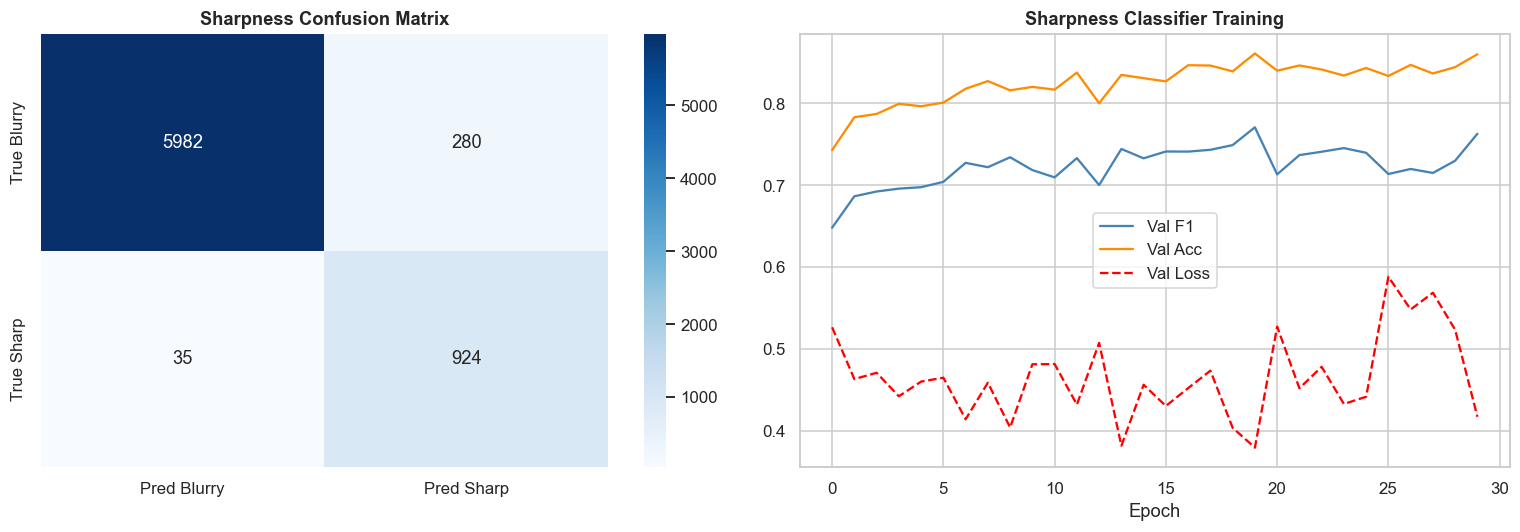


💾 Saved: reports/sharpness_classifier_eval.png
💾 Saved: reports/sharpness_metrics.json


In [8]:
def evaluate_classifier(model, df, label_col, split_name, transform):
    ds = CropDataset(df[df["split"] == split_name], label_col, transform=transform)
    
    # num_workers=0 — fixes Windows slowdown
    loader = DataLoader(ds, batch_size=64, shuffle=False,
                        num_workers=0, pin_memory=False)

    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs    = imgs.to(DEVICE)
            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1)[:, 1]
            preds   = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


# ── Test set evaluation ────────────────────────────────────────────────────────
y_true, y_pred, y_prob = evaluate_classifier(
    sharpness_model, master_df, "sharpness_label", "test", eval_transform
)

print("=== SHARPNESS CLASSIFIER — TEST SET ===\n")
print(classification_report(y_true, y_pred,
      target_names=["Blurry (0)", "Sharp (1)"], digits=4))

cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred Blurry","Pred Sharp"],
            yticklabels=["True Blurry","True Sharp"])
axes[0].set_title("Sharpness Confusion Matrix", fontweight="bold")

axes[1].plot(sharp_history["val_f1"],   label="Val F1",   color="steelblue")
axes[1].plot(sharp_history["val_acc"],  label="Val Acc",  color="darkorange")
axes[1].plot(sharp_history["val_loss"], label="Val Loss", color="red", linestyle="--")
axes[1].set_title("Sharpness Classifier Training", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_PATH / "sharpness_classifier_eval.png", bbox_inches="tight")
plt.show()

sharp_metrics = {
    "f1_macro"  : float(f1_score(y_true, y_pred, average="macro")),
    "f1_sharp"  : float(f1_score(y_true, y_pred, pos_label=1, average="binary")),
    "f1_blurry" : float(f1_score(y_true, y_pred, pos_label=0, average="binary")),
    "precision" : float(precision_score(y_true, y_pred, average="macro")),
    "recall"    : float(recall_score(y_true, y_pred, average="macro")),
    "roc_auc"   : float(roc_auc_score(y_true, y_prob)),
}
with open(REPORTS_PATH / "sharpness_metrics.json", "w") as f:
    json.dump(sharp_metrics, f, indent=2)

print(f"\n💾 Saved: reports/sharpness_classifier_eval.png")
print(f"💾 Saved: reports/sharpness_metrics.json")

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# VLAD'S TASK — Occlusion Classifier
#
# Class distribution: 59.5% occluded / 40.5% visible
# Less imbalanced than sharpness — class weights still applied for fairness.
# ─────────────────────────────────────────────────────────────────────────────

BATCH_SIZE = 64

train_occ_df = master_df[master_df["split"] == "train"]
val_occ_df   = master_df[master_df["split"] == "val"]

train_occ_ds = CropDataset(train_occ_df, "occlusion_label", transform=train_transform)
val_occ_ds   = CropDataset(val_occ_df,   "occlusion_label", transform=eval_transform)

# num_workers=0 and pin_memory=False — fixes Windows hanging issue
train_occ_loader = DataLoader(train_occ_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0, pin_memory=False)
val_occ_loader   = DataLoader(val_occ_ds,   batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=0, pin_memory=False)

print(f"Device        : {DEVICE}")
print(f"Train crops   : {len(train_occ_ds)}")
print(f"Val crops     : {len(val_occ_ds)}")
print(f"Batches/epoch : {len(train_occ_loader)}")

n_visible  = (train_occ_df["occlusion_label"] == 0).sum()
n_occluded = (train_occ_df["occlusion_label"] == 1).sum()
w_visible  = len(train_occ_df) / (2 * n_visible)
w_occluded = len(train_occ_df) / (2 * n_occluded)
occ_weights = torch.tensor([w_visible, w_occluded], dtype=torch.float32)

print(f"\nClass weights:")
print(f"  Visible  (0): {w_visible:.3f}")
print(f"  Occluded (1): {w_occluded:.3f}")

occlusion_model = build_classifier(num_classes=2, pretrained=True)

print("\nTraining occlusion classifier...")
occlusion_model, occ_history = train_classifier(
    occlusion_model,
    train_occ_loader,
    val_occ_loader,
    n_epochs      = 30,
    lr            = 1e-4,
    class_weights = occ_weights,
    save_name     = "occlusion_classifier"
)

Device        : cuda
Train crops   : 37240
Val crops     : 10925
Batches/epoch : 582

Class weights:
  Visible  (0): 1.185
  Occluded (1): 0.865

Training occlusion classifier...
  Epoch   1/30 [██████████████████████████████] 582/582 loss: 0.6901 ETA: 0s    
  → train_loss: 0.6901 | val_loss: 0.7791 | val_F1: 0.4736 | val_acc: 0.4762 | epoch: 100s | ETA: 48.2min ⬆ BEST
  Epoch   2/30 [██████████████████████████████] 582/582 loss: 0.6233 ETA: 0s    
  → train_loss: 0.6233 | val_loss: 0.7846 | val_F1: 0.4723 | val_acc: 0.4781 | epoch: 104s | ETA: 47.5min 
  Epoch   3/30 [██████████████████████████████] 582/582 loss: 0.5799 ETA: 0s    
  → train_loss: 0.5799 | val_loss: 0.8107 | val_F1: 0.4775 | val_acc: 0.4881 | epoch: 103s | ETA: 45.9min ⬆ BEST
  Epoch   4/30 [██████████████████████████████] 582/582 loss: 0.5412 ETA: 0s    
  → train_loss: 0.5412 | val_loss: 0.8706 | val_F1: 0.4636 | val_acc: 0.4731 | epoch: 108s | ETA: 44.9min 
  Epoch   5/30 [██████████████████████████████] 582/582 l

=== OCCLUSION CLASSIFIER — TEST SET ===

              precision    recall  f1-score   support

 Visible (0)     0.5295    0.6166    0.5698      2705
Occluded (1)     0.7453    0.6718    0.7066      4516

    accuracy                         0.6512      7221
   macro avg     0.6374    0.6442    0.6382      7221
weighted avg     0.6645    0.6512    0.6554      7221



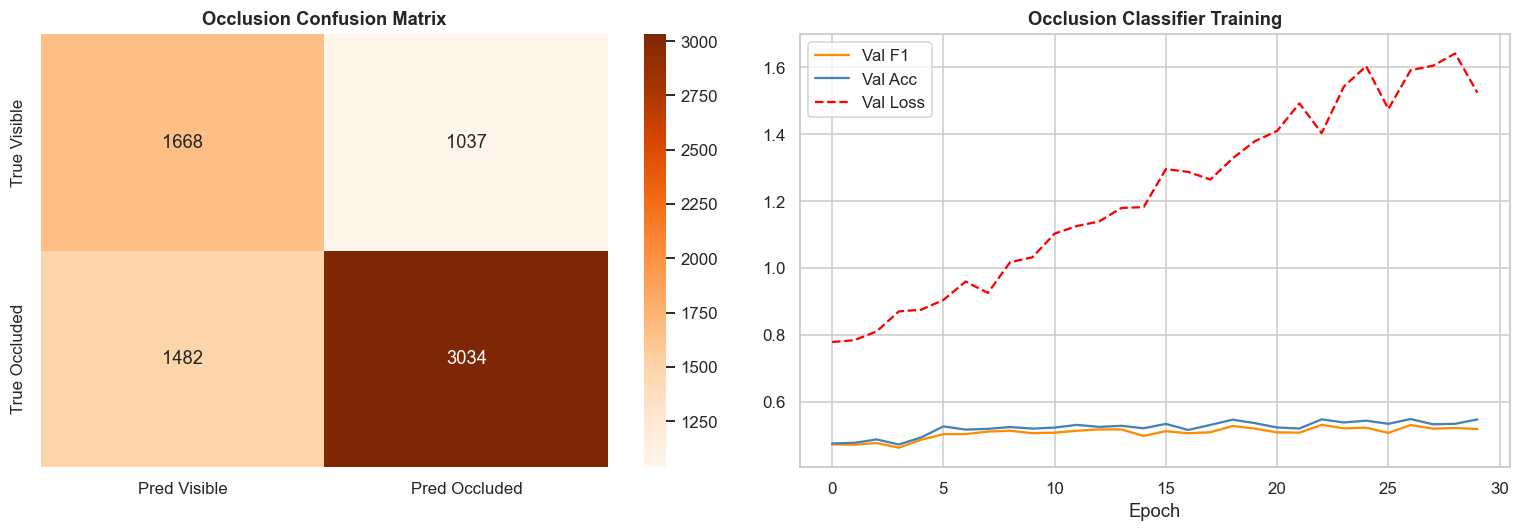


💾 Saved: reports/occlusion_classifier_eval.png
💾 Saved: reports/occlusion_metrics.json


In [10]:
y_true_occ, y_pred_occ, y_prob_occ = evaluate_classifier(
    occlusion_model, master_df, "occlusion_label", "test", eval_transform
)

print("=== OCCLUSION CLASSIFIER — TEST SET ===\n")
print(classification_report(y_true_occ, y_pred_occ,
      target_names=["Visible (0)", "Occluded (1)"], digits=4))

cm_occ = confusion_matrix(y_true_occ, y_pred_occ)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_occ, annot=True, fmt="d", cmap="Oranges", ax=axes[0],
            xticklabels=["Pred Visible","Pred Occluded"],
            yticklabels=["True Visible","True Occluded"])
axes[0].set_title("Occlusion Confusion Matrix", fontweight="bold")

axes[1].plot(occ_history["val_f1"],   label="Val F1",   color="darkorange")
axes[1].plot(occ_history["val_acc"],  label="Val Acc",  color="steelblue")
axes[1].plot(occ_history["val_loss"], label="Val Loss", color="red", linestyle="--")
axes[1].set_title("Occlusion Classifier Training", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_PATH / "occlusion_classifier_eval.png", bbox_inches="tight")
plt.show()

occ_metrics = {
    "f1_macro"    : float(f1_score(y_true_occ, y_pred_occ, average="macro")),
    "f1_occluded" : float(f1_score(y_true_occ, y_pred_occ, pos_label=1, average="binary")),
    "f1_visible"  : float(f1_score(y_true_occ, y_pred_occ, pos_label=0, average="binary")),
    "precision"   : float(precision_score(y_true_occ, y_pred_occ, average="macro")),
    "recall"      : float(recall_score(y_true_occ, y_pred_occ, average="macro")),
    "roc_auc"     : float(roc_auc_score(y_true_occ, y_prob_occ)),
}
with open(REPORTS_PATH / "occlusion_metrics.json", "w") as f:
    json.dump(occ_metrics, f, indent=2)

print(f"\n💾 Saved: reports/occlusion_classifier_eval.png")
print(f"💾 Saved: reports/occlusion_metrics.json")

Matched detections to ground truth: 7130


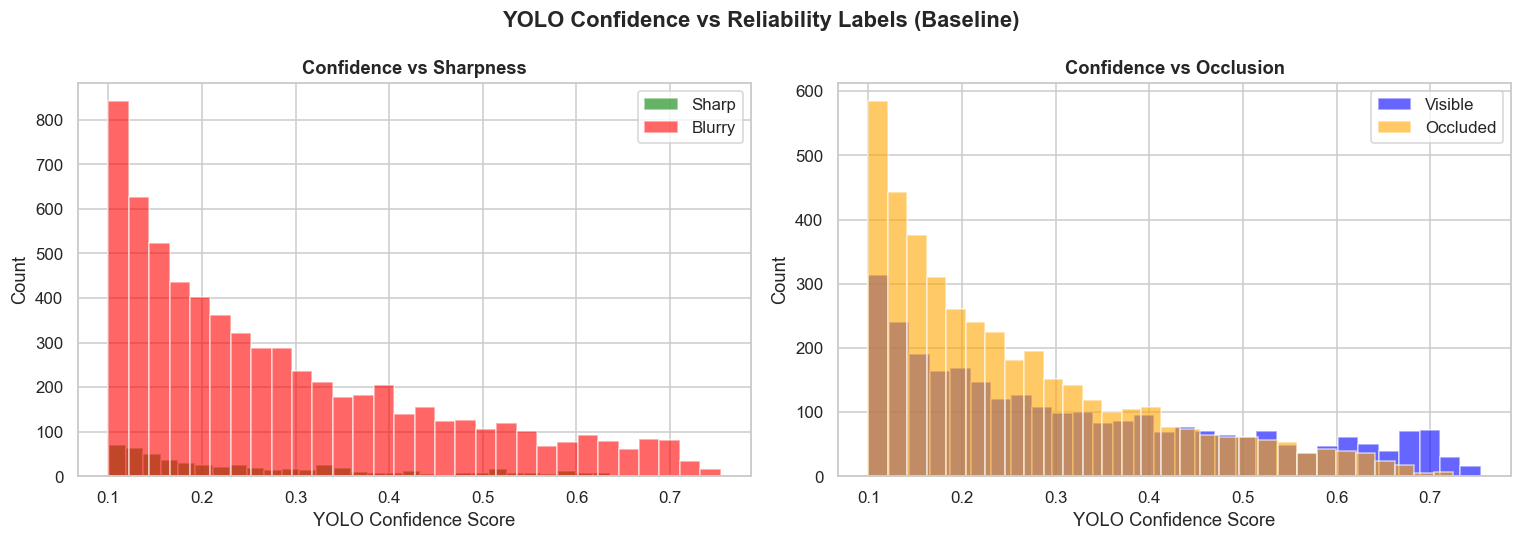


Mean confidence by sharpness:
  Sharp  : 0.264
  Blurry : 0.286

Mean confidence by occlusion:
  Visible  : 0.322
  Occluded : 0.258


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# The key question: does YOLO's own confidence score already predict
# whether a detection is sharp or occluded?
#
# If YOLO confidence is a perfect predictor → our classifiers add no value.
# If YOLO confidence is a weak predictor   → our classifiers are justified.
#
# We match detections to ground truth labels by image name + closest box.
# ─────────────────────────────────────────────────────────────────────────────

detections_csv = REPORTS_PATH / "yolo_test_detections.csv"

if not detections_csv.exists():
    print("⚠️  Run Cell 7 (YOLO inference) first to generate detections.")
else:
    det_df   = pd.read_csv(detections_csv)
    test_df  = master_df[master_df["split"] == "test"].copy()

    # Match detections to ground truth crops by image name and nearest box center
    def match_detection_to_crop(det_row, crop_rows):
        """Find the crop annotation closest to a detection box center."""
        if len(crop_rows) == 0:
            return None
        dists = np.sqrt(
            (crop_rows["x_center"] - det_row["x_center"])**2 +
            (crop_rows["y_center"] - det_row["y_center"])**2
        )
        idx = dists.idxmin()
        if dists[idx] < 0.05:   # must be within 5% of image size
            return idx
        return None

    matched = []
    for img_name, det_group in det_df.groupby("image"):
        img_crops = test_df[test_df["source_image"] == img_name]
        for _, det_row in det_group.iterrows():
            match_idx = match_detection_to_crop(det_row, img_crops)
            if match_idx is not None:
                crop_row = img_crops.loc[match_idx]
                matched.append({
                    "conf"            : det_row["conf"],
                    "sharpness_label" : crop_row["sharpness_label"],
                    "occlusion_label" : crop_row["occlusion_label"],
                })

    matched_df = pd.DataFrame(matched)
    print(f"Matched detections to ground truth: {len(matched_df)}")

    # ── Does confidence correlate with sharpness? ─────────────────────────────
    sharp_conf  = matched_df[matched_df["sharpness_label"] == 1]["conf"]
    blurry_conf = matched_df[matched_df["sharpness_label"] == 0]["conf"]

    # ── Does confidence correlate with occlusion? ─────────────────────────────
    visible_conf  = matched_df[matched_df["occlusion_label"] == 0]["conf"]
    occluded_conf = matched_df[matched_df["occlusion_label"] == 1]["conf"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("YOLO Confidence vs Reliability Labels (Baseline)", fontweight="bold")

    axes[0].hist(sharp_conf,  bins=30, alpha=0.6, label="Sharp",  color="green")
    axes[0].hist(blurry_conf, bins=30, alpha=0.6, label="Blurry", color="red")
    axes[0].set_title("Confidence vs Sharpness", fontweight="bold")
    axes[0].set_xlabel("YOLO Confidence Score")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    axes[1].hist(visible_conf,  bins=30, alpha=0.6, label="Visible",  color="blue")
    axes[1].hist(occluded_conf, bins=30, alpha=0.6, label="Occluded", color="orange")
    axes[1].set_title("Confidence vs Occlusion", fontweight="bold")
    axes[1].set_xlabel("YOLO Confidence Score")
    axes[1].set_ylabel("Count")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(REPORTS_PATH / "baseline_confidence_analysis.png", bbox_inches="tight")
    plt.show()

    print(f"\nMean confidence by sharpness:")
    print(f"  Sharp  : {sharp_conf.mean():.3f}")
    print(f"  Blurry : {blurry_conf.mean():.3f}")
    print(f"\nMean confidence by occlusion:")
    print(f"  Visible  : {visible_conf.mean():.3f}")
    print(f"  Occluded : {occluded_conf.mean():.3f}")

In [13]:
# ── Recreate all variables needed for the analysis cells ──────────────────────
# Run this after a kernel restart instead of re-running Cells 3-7
# Everything is loaded from disk — no retraining needed

from ultralytics import YOLO
from pathlib import Path

# Find best.pt on disk
weight_matches = list(Path(".").glob("**/yolo11s_bambi/weights/best.pt"))
if not weight_matches:
    raise FileNotFoundError(
        "❌ best.pt not found on disk.\n"
        "   This means YOLO training (Cell 4) never finished successfully.\n"
        "   You need to re-run Cell 4 once."
    )

best_weights = weight_matches[0]
print(f"✅ best_weights : {best_weights}")

# Find yaml_path
yaml_path = SPLIT_PATH / "dataset.yaml"
print(f"✅ yaml_path    : {yaml_path}")

# Find results.csv for training curves
csv_matches = list(Path(".").glob("**/yolo11s_bambi/results.csv"))
results_csv = csv_matches[0] if csv_matches else None
print(f"✅ results_csv  : {results_csv}")

# Confirm test images exist
test_img_dir = SPLIT_PATH / "test" / "images"
test_imgs    = list(test_img_dir.glob("*"))
print(f"✅ Test images  : {len(test_imgs)}")

print("\n✅ All YOLO variables restored from disk — ready for Cells 16 and 17")

✅ best_weights : runs\detect\models\yolo11s_bambi\weights\best.pt
✅ yaml_path    : dataset_split\dataset.yaml
✅ results_csv  : runs\detect\models\yolo11s_bambi\results.csv
✅ Test images  : 2712

✅ All YOLO variables restored from disk — ready for Cells 16 and 17


Computing mAP per reliability group...

  sharp_visible       : 75 images, 105 annotations
  sharp_occluded      : 186 images, 854 annotations
  blurry_visible      : 965 images, 2600 annotations
  blurry_occluded     : 1897 images, 3662 annotations

4-way detection performance:

                 precision  recall      f1  mean_conf  n_images  n_gt_boxes
sharp_visible       0.3370  0.8857  0.4882     0.2817      75.0       105.0
sharp_occluded      0.6895  0.6710  0.6801     0.2607     186.0       854.0
blurry_visible      0.4796  0.8469  0.6124     0.3013     965.0      2600.0
blurry_occluded     0.4163  0.6980  0.5215     0.2642    1897.0      3662.0


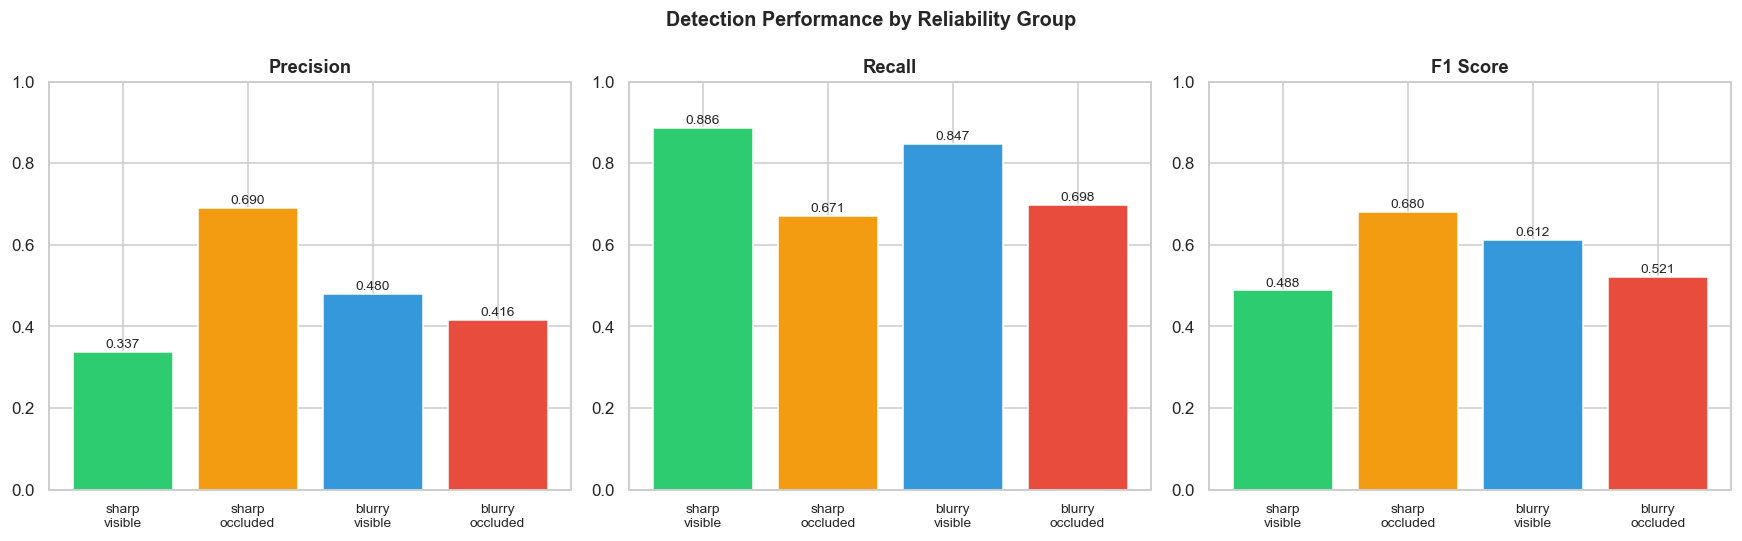


💾 Saved: reports/reliability_group_analysis.png


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# THE KEY ANALYSIS from your evaluation slide:
# Compare mAP across the 4 label combinations.
# Hypothesis: sharp+visible should have highest mAP, blurry+occluded lowest.
# If this pattern holds, your reliability labels capture real detection difficulty.
# ─────────────────────────────────────────────────────────────────────────────

if best_weights.exists():
    yolo_analysis = YOLO(str(best_weights))

    combo_map_results = {}
    test_img_dir = SPLIT_PATH / "test" / "images"
    test_crops   = master_df[master_df["split"] == "test"].copy()

    combos = {
        "sharp_visible"   : test_crops[(test_crops["sharpness_label"]==1) & (test_crops["occlusion_label"]==0)],
        "sharp_occluded"  : test_crops[(test_crops["sharpness_label"]==1) & (test_crops["occlusion_label"]==1)],
        "blurry_visible"  : test_crops[(test_crops["sharpness_label"]==0) & (test_crops["occlusion_label"]==0)],
        "blurry_occluded" : test_crops[(test_crops["sharpness_label"]==0) & (test_crops["occlusion_label"]==1)],
    }

    print("Computing mAP per reliability group...\n")

    for combo_name, combo_df in combos.items():
        # Get unique images for this combo
        combo_images = combo_df["source_image"].unique()
        print(f"  {combo_name:<20}: {len(combo_images)} images, {len(combo_df)} annotations")

        # Run YOLO val on just these images by creating a temp image list
        # We collect predictions and compute mAP manually via confidence thresholding
        total_tp = 0
        total_fp = 0
        total_fn = 0
        confs    = []

        for img_name in combo_images:
            img_path = test_img_dir / img_name
            if not img_path.exists():
                continue

            preds = yolo_analysis.predict(str(img_path), imgsz=1280,
                                          conf=0.1, verbose=False)
            n_pred = len(preds[0].boxes) if preds[0].boxes else 0
            n_gt   = len(combo_df[combo_df["source_image"] == img_name])

            # Simple TP/FP/FN estimate (rough — proper mAP needs IoU matching)
            tp = min(n_pred, n_gt)
            fp = max(0, n_pred - n_gt)
            fn = max(0, n_gt - n_pred)
            total_tp += tp
            total_fp += fp
            total_fn += fn

            if preds[0].boxes:
                confs.extend(preds[0].boxes.conf.cpu().numpy().tolist())

        precision = total_tp / (total_tp + total_fp + 1e-6)
        recall    = total_tp / (total_tp + total_fn + 1e-6)
        f1        = 2 * precision * recall / (precision + recall + 1e-6)
        mean_conf = np.mean(confs) if confs else 0.0

        combo_map_results[combo_name] = {
            "precision" : round(precision, 4),
            "recall"    : round(recall, 4),
            "f1"        : round(f1, 4),
            "mean_conf" : round(mean_conf, 4),
            "n_images"  : len(combo_images),
            "n_gt_boxes": len(combo_df),
        }

    # ── Visualise results ─────────────────────────────────────────────────────
    results_df = pd.DataFrame(combo_map_results).T
    print(f"\n4-way detection performance:\n")
    print(results_df.to_string())

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Detection Performance by Reliability Group", fontsize=13, fontweight="bold")

    colors = ["#2ecc71","#f39c12","#3498db","#e74c3c"]
    labels = list(combo_map_results.keys())

    for ax, metric, title in zip(axes, ["precision","recall","f1"],
                                  ["Precision","Recall","F1 Score"]):
        vals = [combo_map_results[l][metric] for l in labels]
        bars = ax.bar(range(len(labels)), vals, color=colors)
        ax.set_title(title, fontweight="bold")
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels([l.replace("_","\n") for l in labels], fontsize=9)
        ax.set_ylim(0, 1)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    val + 0.01, f"{val:.3f}", ha="center", fontsize=9)

    plt.tight_layout()
    plt.savefig(REPORTS_PATH / "reliability_group_analysis.png", bbox_inches="tight")
    plt.show()

    with open(REPORTS_PATH / "reliability_group_metrics.json", "w") as f:
        json.dump(combo_map_results, f, indent=2)
    print(f"\n💾 Saved: reports/reliability_group_analysis.png")

In [15]:
# Load all saved metrics
yolo_m  = json.load(open(REPORTS_PATH / "yolo_test_metrics.json"))     if (REPORTS_PATH / "yolo_test_metrics.json").exists()     else {}
sharp_m = json.load(open(REPORTS_PATH / "sharpness_metrics.json"))     if (REPORTS_PATH / "sharpness_metrics.json").exists()     else {}
occ_m   = json.load(open(REPORTS_PATH / "occlusion_metrics.json"))     if (REPORTS_PATH / "occlusion_metrics.json").exists()     else {}
group_m = json.load(open(REPORTS_PATH / "reliability_group_metrics.json")) if (REPORTS_PATH / "reliability_group_metrics.json").exists() else {}

print("=" * 60)
print("  WEEK 3 — FINAL RESULTS SUMMARY")
print("=" * 60)

print(f"\n📦 SECTION A — YOLOv11 Detection (Test Set)")
if yolo_m:
    print(f"  mAP@0.5     : {yolo_m.get('mAP50', 'N/A'):.4f}")
    print(f"  mAP@0.5:0.95: {yolo_m.get('mAP50_95', 'N/A'):.4f}")
    print(f"  Precision   : {yolo_m.get('precision', 'N/A'):.4f}")
    print(f"  Recall      : {yolo_m.get('recall', 'N/A'):.4f}")

print(f"\n🔍 SECTION B — Sharpness Classifier (Test Set)")
if sharp_m:
    print(f"  F1 Macro    : {sharp_m.get('f1_macro', 'N/A'):.4f}")
    print(f"  F1 Sharp    : {sharp_m.get('f1_sharp', 'N/A'):.4f}")
    print(f"  F1 Blurry   : {sharp_m.get('f1_blurry', 'N/A'):.4f}")
    print(f"  ROC-AUC     : {sharp_m.get('roc_auc', 'N/A'):.4f}")

print(f"\n👁️  SECTION C — Occlusion Classifier (Test Set)")
if occ_m:
    print(f"  F1 Macro    : {occ_m.get('f1_macro', 'N/A'):.4f}")
    print(f"  F1 Occluded : {occ_m.get('f1_occluded', 'N/A'):.4f}")
    print(f"  F1 Visible  : {occ_m.get('f1_visible', 'N/A'):.4f}")
    print(f"  ROC-AUC     : {occ_m.get('roc_auc', 'N/A'):.4f}")

print(f"\n📊 SECTION D — Detection by Reliability Group")
if group_m:
    print(f"  {'Group':<20} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("  " + "-" * 52)
    for group, metrics in group_m.items():
        print(f"  {group:<20} {metrics['precision']:>10.4f} "
              f"{metrics['recall']:>10.4f} {metrics['f1']:>10.4f}")

print(f"\n{'='*60}")
print(f"All figures saved to: {REPORTS_PATH.resolve()}")

  WEEK 3 — FINAL RESULTS SUMMARY

📦 SECTION A — YOLOv11 Detection (Test Set)
  mAP@0.5     : 0.1847
  mAP@0.5:0.95: 0.0631
  Precision   : 0.3080
  Recall      : 0.2038

🔍 SECTION B — Sharpness Classifier (Test Set)
  F1 Macro    : 0.9144
  F1 Sharp    : 0.8544
  F1 Blurry   : 0.9743
  ROC-AUC     : 0.9923

👁️  SECTION C — Occlusion Classifier (Test Set)
  F1 Macro    : 0.6382
  F1 Occluded : 0.7066
  F1 Visible  : 0.5698
  ROC-AUC     : 0.7100

📊 SECTION D — Detection by Reliability Group
  Group                 Precision     Recall         F1
  ----------------------------------------------------
  sharp_visible            0.3370     0.8857     0.4882
  sharp_occluded           0.6895     0.6710     0.6801
  blurry_visible           0.4796     0.8469     0.6124
  blurry_occluded          0.4163     0.6980     0.5215

All figures saved to: C:\Users\klevi\Desktop\Computer Vision\reports
